# ARMA(1,1) Model with `numpyro_forecast`

This notebook ports the blog post [**Notes on an ARMA(1,1) Model with
NumPyro**](https://juanitorduz.github.io/arma_numpyro/) to the
[`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast)
package. Autoregressive moving average (ARMA) models are the workhorse
of classical time series analysis, and the $(1,1)$ member is the
smallest one that combines both mechanisms: an autoregressive term that
feeds the previous *observation* back into the mean, and a moving
average term that feeds the previous *forecast error* back. We simulate
data from an ARMA(1,1) process, so we own the data generating process
and can verify that the model recovers the true parameters, and we fit
it with MCMC (the NUTS sampler) through plain NumPyro.

Two deliberate changes from the blog post are worth calling out:

- Instead of a single train-test split, we evaluate with
  **expanding-window time-slice cross-validation** via
  `numpyro_forecast.backtest`, scoring every fold with the continuous
  ranked probability score (CRPS) and the empirical coverage of the
  central $50\%$ and $94\%$ intervals, both in-sample and out-of-sample,
  exactly as in the [univariate forecasting
  example](https://juanitorduz.github.io/numpyro_forecast/docs/examples/forecasting_univariate.html).
- The forecast path is fully **generative**: over the horizon we sample
  future innovations and feed them back into the ARMA recursion, so the
  forecast uncertainty compounds correctly step by step. The blog post
  instead zeroed the future errors inside its prediction loop, which
  understates the multi-step uncertainty.

A practical note on the design, in the same spirit as the [exponential
smoothing
example](https://juanitorduz.github.io/numpyro_forecast/docs/examples/exponential_smoothing_state_space.html):
the
[`innovations`](https://juanitorduz.github.io/numpyro_forecast/reference/models.innovations.html)
and
[`predict`](https://juanitorduz.github.io/numpyro_forecast/reference/models.predict.html)
building blocks assume a deterministic mean plus independent per-step
noise, which cannot express ARMA’s recursive dependence on past
observations and errors. The package’s
[`ssoe`](https://juanitorduz.github.io/numpyro_forecast/reference/models.ssoe.html)
building block (single source of error) is made for exactly this shape
of model: it runs the in-sample error-feedback filter and the generative
forecast recursion, and we register the `"obs"` and `"forecast"` sites
ourselves while reusing everything downstream: `to_datatree`,
`forecast`, `predict_in_sample`, and `backtest`. And since an ARMA model
is, at heart, a regression on the *lagged series itself*, the observed
series plays the role of the covariates: `ssoe` takes the driving series
as an argument, and the package’s `predict_in_sample` and `to_datatree`
call the model with `data=None`, so the history has to travel through
`covariates`, which spans the full horizon and is available at
prediction time. The model only ever reads the first `t_obs` rows (the
block checks this), so no future information leaks into a forecast.

## Prepare notebook

In [1]:
from functools import partial

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
from jax import random
from jaxtyping import Float
from numpyro.infer import MCMC, NUTS

from numpyro_forecast import (
    Horizon,
    backtest,
    eval_coverage,
    eval_crps,
    forecast,
    predict_in_sample,
    predictions_to_datatree,
    ssoe,
    to_datatree,
)
from numpyro_forecast.acf import acf, pacf
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)


%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Generate data

The ARMA(1,1) process is defined by the recursion

$$y_t = \phi \, y_{t-1} + \theta \, \varepsilon_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, \sigma),$$

where $\phi$ is the autoregressive coefficient, $\theta$ the moving
average coefficient, and $\sigma$ the innovation scale. We simulate
$T = 100$ observations with $\phi = 0.4$, $\theta = 0.7$, and
$\sigma = 0.5$ (one extra step initializes the recursion and is
dropped). As in the blog post, we write the simulation twice: first as a
transparent Python loop, then with
[`jax.lax.scan`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html),
which compiles the recursion into a single efficient operation and is
the idiom the `ssoe` block uses inside the model. Compared to the blog
we tighten the type hints: the key takes the package-wide `Array` type
and the return shape is spelled out with a
[jaxtyping](https://docs.kidger.site/jaxtyping/) annotation.

In [2]:
phi_true = 0.4
theta_true = 0.7
noise_scale = 0.5
n_samples = 100 + 1  # one extra step to initialize the recursion


def generate_arma_1_1_data_for_loop(
    rng_key: Array, n_samples: int, phi: float, theta: float, noise_scale: float
) -> Float[Array, " t"]:
    """Simulate an ARMA(1,1) series with an explicit Python loop.

    Parameters
    ----------
    rng_key
        PRNG key for the innovations.
    n_samples
        Number of steps to simulate; the initial step is dropped, so the
        returned series has ``n_samples - 1`` entries.
    phi
        Autoregressive coefficient.
    theta
        Moving average coefficient.
    noise_scale
        Scale of the Gaussian innovations.

    Returns
    -------
    Float[Array, " t"]
        The simulated series of length ``n_samples - 1``.
    """
    error = noise_scale * random.normal(rng_key, (n_samples,))
    y = jnp.zeros(n_samples)
    for t in range(1, n_samples):
        y = y.at[t].set(phi * y[t - 1] + theta * error[t - 1] + error[t])
    return y[1:]


rng_key, rng_subkey = random.split(rng_key)
y_for_loop = generate_arma_1_1_data_for_loop(
    rng_subkey, n_samples, phi_true, theta_true, noise_scale
)
print(f"series shape: {y_for_loop.shape}")

series shape: (100,)

The scan version threads a carry `(y_prev, error_prev)` through the
innovations and produces the same series. Because JAX keys are pure,
reusing `rng_subkey` reproduces the innovations bit for bit, so we can
also print their realized standard deviation: with only $T = 100$ draws
it lands visibly below the population value $\sigma = 0.5$, a fact we
will need when judging the parameter recovery below.

In [3]:
def generate_arma_1_1_data_scan(
    rng_key: Array, n_samples: int, phi: float, theta: float, noise_scale: float
) -> Float[Array, " t"]:
    """Simulate an ARMA(1,1) series with `jax.lax.scan()`.

    Parameters
    ----------
    rng_key
        PRNG key for the innovations.
    n_samples
        Number of steps to simulate; the initial step is dropped, so the
        returned series has ``n_samples - 1`` entries.
    phi
        Autoregressive coefficient.
    theta
        Moving average coefficient.
    noise_scale
        Scale of the Gaussian innovations.

    Returns
    -------
    Float[Array, " t"]
        The simulated series of length ``n_samples - 1``.
    """
    error = noise_scale * random.normal(rng_key, (n_samples,))

    def arma_step(carry, noise):
        y_prev, error_prev = carry
        y_t = phi * y_prev + theta * error_prev + noise
        return (y_t, noise), y_t

    _, y = jax.lax.scan(arma_step, (jnp.zeros(()), error[0]), error[1:])
    return y


y = generate_arma_1_1_data_scan(rng_subkey, n_samples, phi_true, theta_true, noise_scale)
print(f"for-loop and scan agree: {jnp.allclose(y_for_loop, y, atol=1e-6)}")

eps_realized = noise_scale * random.normal(rng_subkey, (n_samples,))
print(f"realized innovation sd: {eps_realized.std():.2f} (population value: {noise_scale})")

for-loop and scan agree: True
realized innovation sd: 0.43 (population value: 0.5)

Throughout the package, time lives at axis `-2` and the observation
dimension at axis `-1`, so the single series has shape `(100, 1)`.
Following the design note above, the same array also serves as the
covariates.

data shape: (100, 1)

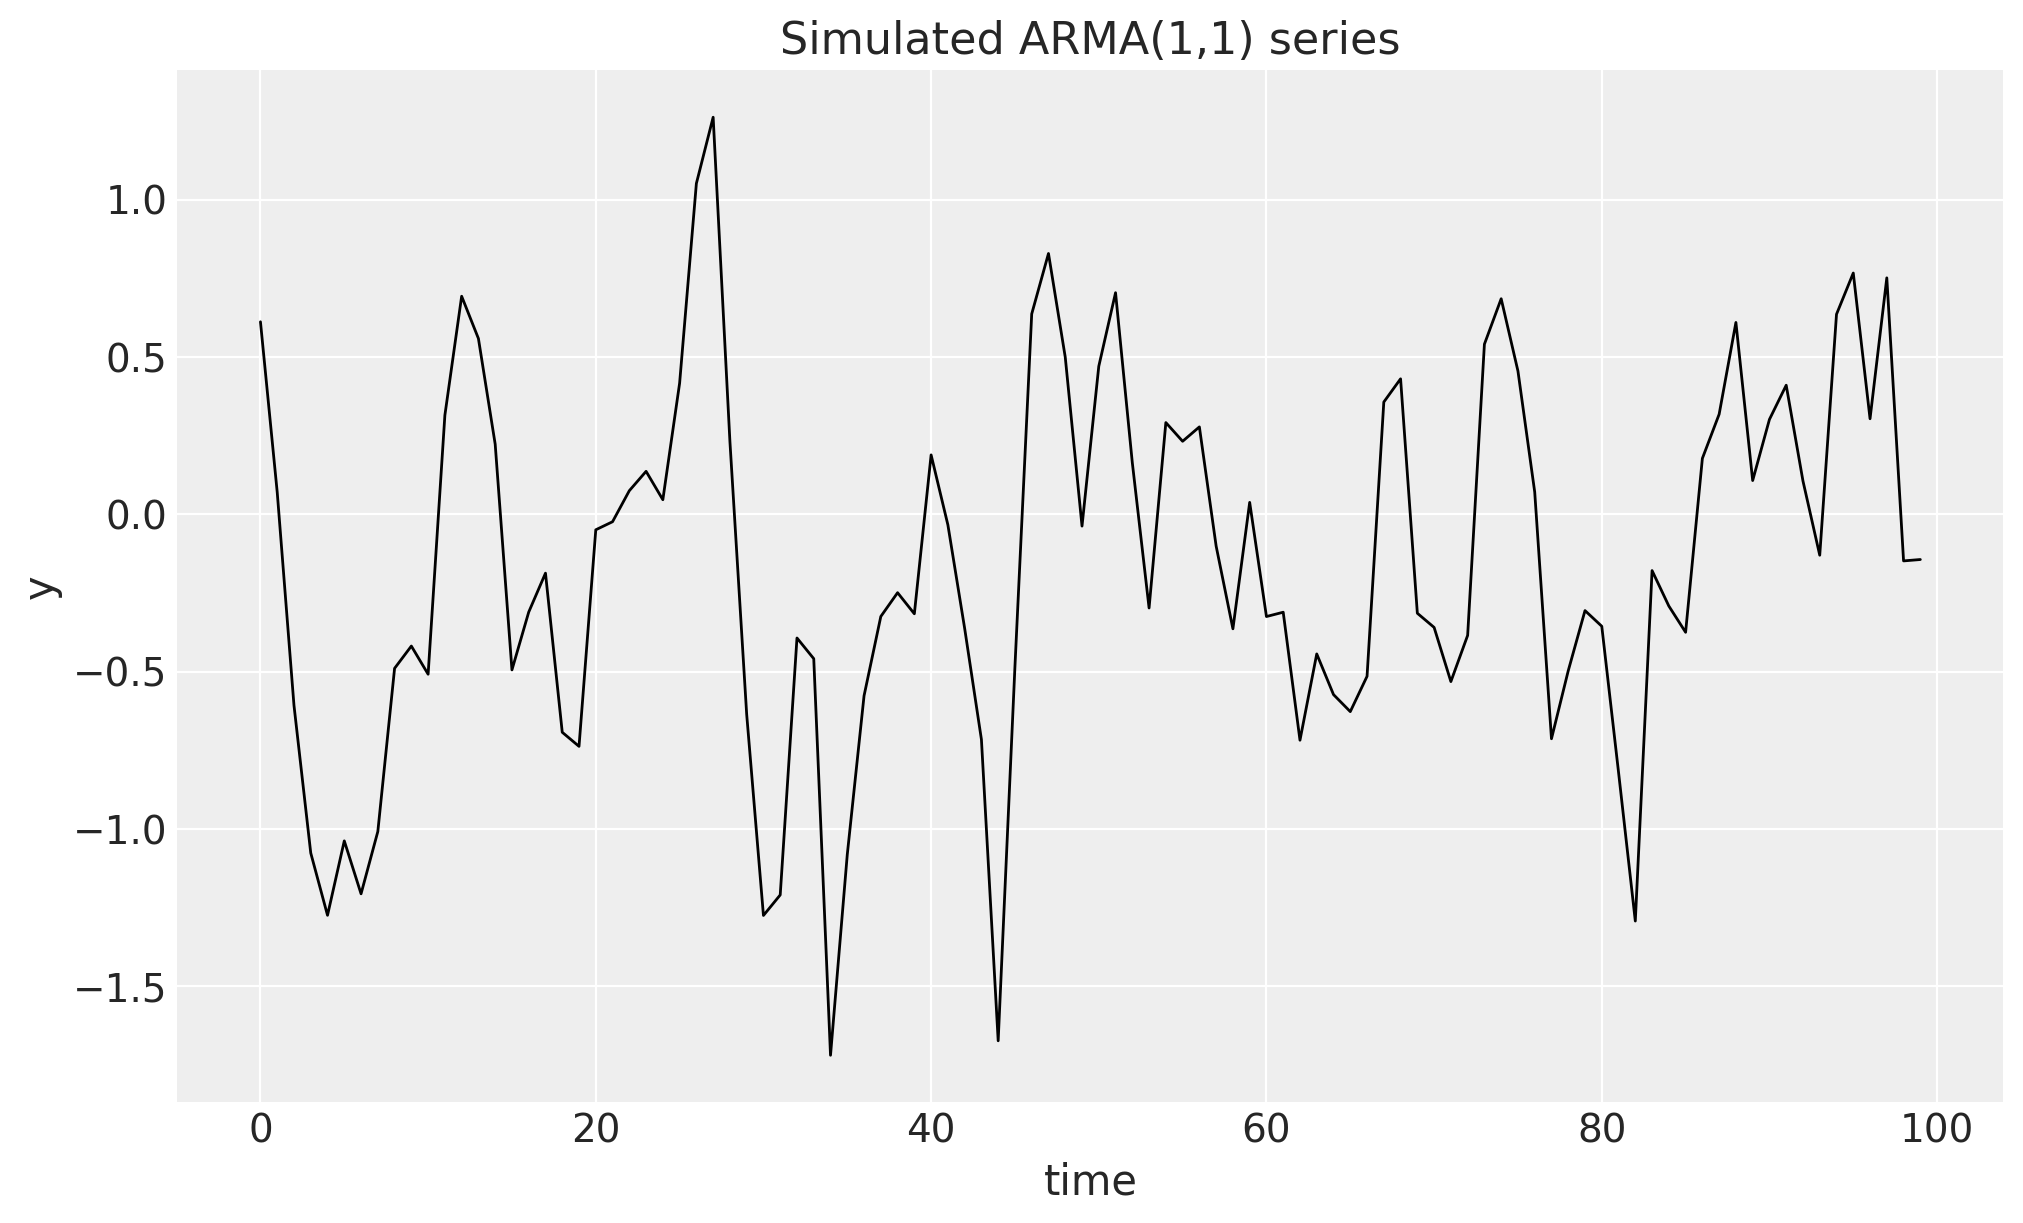

In [4]:
data = y[:, None]
covariates = data  # the lagged series is the "covariate" of an ARMA model
duration = data.shape[-2]
time = np.arange(duration)
print(f"data shape: {data.shape}")

fig, ax = plt.subplots()
ax.plot(time, y, color="black", lw=1)
ax.set(title="Simulated ARMA(1,1) series", xlabel="time", ylabel="y");

## ACF and PACF

Before modeling, we look at the empirical autocorrelation function (ACF)
and partial autocorrelation function (PACF), the classical tools for
identifying ARMA orders. The blog post used the statsmodels plotting
helpers; here we use the package’s own
[`acf`](https://juanitorduz.github.io/numpyro_forecast/reference/acf.acf.html)
and
[`pacf`](https://juanitorduz.github.io/numpyro_forecast/reference/acf.pacf.html)
functions from `numpyro_forecast.acf`. Both are jitted, compute the ACF
for all lags at once via the FFT, derive the PACF through the
Durbin-Levinson recursion, and broadcast over leading batch axes, so the
same call works on a panel of series (with time on the last axis).

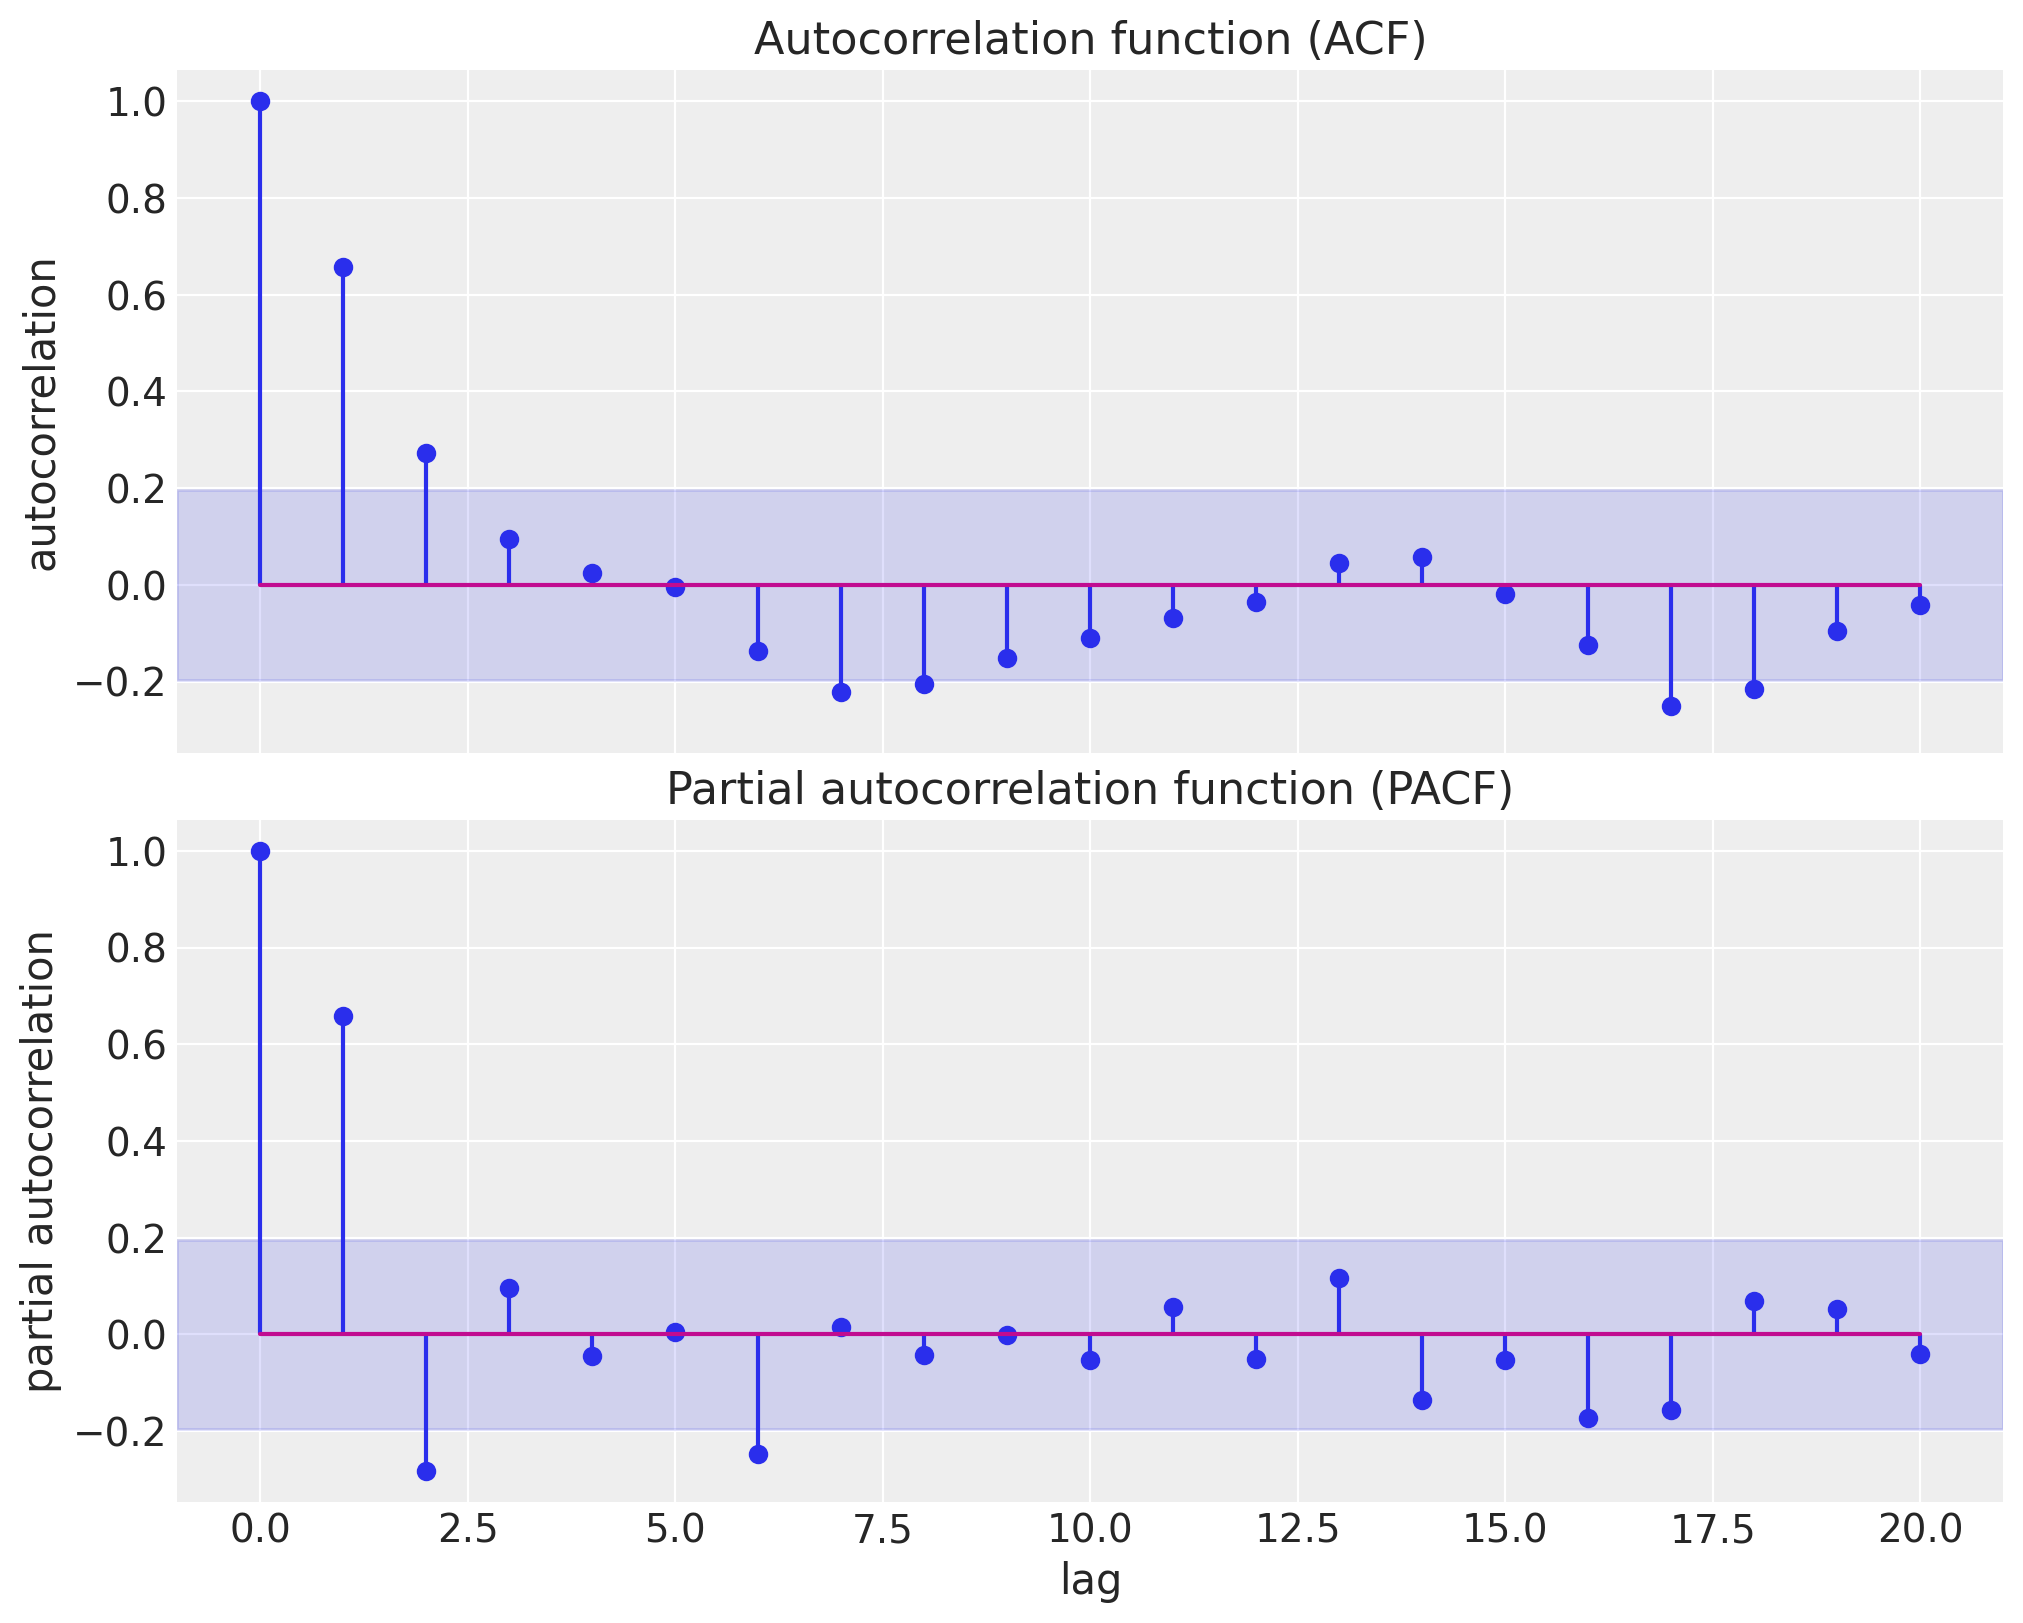

In [5]:
max_lag = 20
lags = np.arange(max_lag + 1)
significance_bound = 1.96 / np.sqrt(duration)

fig, (ax_acf, ax_pacf) = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 8), sharex=True, sharey=True, layout="constrained"
)
ax_acf.stem(lags, np.asarray(acf(y, max_lag)))
ax_acf.axhspan(-significance_bound, significance_bound, color="C0", alpha=0.15)
ax_acf.set(title="Autocorrelation function (ACF)", ylabel="autocorrelation")
ax_pacf.stem(lags, np.asarray(pacf(y, max_lag)))
ax_pacf.axhspan(-significance_bound, significance_bound, color="C0", alpha=0.15)
ax_pacf.set(
    title="Partial autocorrelation function (PACF)",
    xlabel="lag",
    ylabel="partial autocorrelation",
);

The shaded band is the approximate $95\%$ significance region
$\pm 1.96 / \sqrt{T}$ for white noise. The ACF starts high and decays
geometrically over the first few lags, while the PACF is large and
positive at lag $1$ and then flips to a significant negative value at
lag $2$ before dying out: a sign-alternating decay rather than a clean
cutoff. Neither function cuts sharply, which is the classical signature
of a mixed ARMA process: a pure AR($p$) model would cut the PACF after
lag $p$, and a pure MA($q$) model would cut the ACF after lag $q$.

## Model specification

The generative model adds a global mean $\mu$ to the recursion and uses
the same priors as the blog post:

$$y_t = \mu + \phi \, y_{t-1} + \theta \, \varepsilon_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, \sigma),$$

The key insight (from the blog post, and the same one behind the
innovations state space form of exponential smoothing) is that *in
sample the errors are deterministic* given the parameters and the
observed data: running the recursion forward, the one-step-ahead
prediction at time $t$ is
$\hat{y}_t = \mu + \phi \, y_{t-1} + \theta \, \varepsilon_{t-1}$ and
the error is simply $\varepsilon_t = y_t - \hat{y}_t$, initialized with
$y_{-1} = \mu$ and $\varepsilon_{-1} = 0$. The whole in-sample
likelihood is then a single Gaussian observation site: conditioning
$y_t \sim \text{Normal}(\hat{y}_t, \sigma)$ is exactly the blog post’s
“condition on the errors” trick,
$\varepsilon_t \sim \text{Normal}(0, \sigma)$, since the two differ only
by a location shift.

The model is a plain NumPyro function `(covariates, data=None)`: its
first line derives the train/forecast split from the shapes with
[`Horizon.from_data`](https://juanitorduz.github.io/numpyro_forecast/reference/models.Horizon.html),
and the recursion is one `ssoe` call. The block takes the driving series
`y`, the initial carry $(y_{-1}, \varepsilon_{-1})$, a `mean` function,
an `update` function, and the innovation distribution;
`mean(carry, x_t)` returns the one-step-ahead mean and
`update(carry, y_t, eps_t, x_t)` builds the next carry, here simply the
day’s value and error. Rows carry the observation axis, so the carry is
`(mu[None], zeros((1,)))` and the mean has shape `(1,)`; the block
checks these shapes. It then owns the two scans:

1.  **In sample.** A deterministic `jax.lax.scan` filters the observed
    series into one-step-ahead means $\hat{y}_t$, returned as `r.mu`
    (exposed as the deterministic site `"mu_t"`), and the `"obs"` site
    conditions the data on them.
2.  **Out of sample.** When `h.future > 0` the block draws the horizon
    innovations from the prior at a separate `"eps_future"` site (under
    its own `time_future` plate), then rolls the recursion forward
    feeding the *sampled* observation and innovation back into the
    carry, and returns the trajectory as `r.y_future`, which we register
    as the deterministic `"forecast"` site the package’s `forecast`
    driver reads. Because `"eps_future"` does not exist while training,
    `Predictive` draws it from the prior at forecast time, so the
    forecast uncertainty compounds over the horizon exactly as the
    generative process says it should.

Neither scan body contains a sample site, which is why the block can run
plain `jax.lax.scan`.

In [6]:
def arma_1_1(covariates: Array, data: Array | None = None) -> None:
    """ARMA(1,1) model with a deterministic in-sample error-feedback filter.

    Parameters
    ----------
    covariates
        The observed series itself, with time at axis ``-2``; only the first
        ``h.t_obs`` rows are read.
    data
        Observed data with time at axis ``-2``, or ``None`` when the drivers
        sample the observation site.
    """
    h = Horizon.from_data(covariates, data)
    y = covariates[..., : h.t_obs, :]  # observed history only; never reads beyond t_obs

    mu = numpyro.sample("mu", dist.Normal(loc=0, scale=1))
    phi = numpyro.sample("phi", dist.Uniform(low=-1, high=1))
    theta = numpyro.sample("theta", dist.Uniform(low=-1, high=1))
    sigma = numpyro.sample("sigma", dist.HalfNormal(scale=1))

    def mean(carry, _):
        y_prev, error_prev = carry
        return mu + phi * y_prev + theta * error_prev

    def update(carry, y_t, eps_t, _):
        return y_t, eps_t

    init_carry = (mu[None], jnp.zeros((1,)))  # y_{-1} = mu and eps_{-1} = 0 seed the recursion
    r = ssoe(h, "eps", y, init_carry, mean, update, dist.Normal(loc=0, scale=sigma))

    numpyro.deterministic("mu_t", r.mu)
    numpyro.sample("obs", dist.Normal(loc=r.mu, scale=sigma), obs=h.data)
    if h.future > 0:
        numpyro.deterministic("forecast", r.y_future)

## Inference with NUTS

We fit the model on the **full series** (no train-test split; the
held-out evaluation comes from the cross-validation below) with plain
NumPyro: the No-U-Turn Sampler through `MCMC`, running $4$ chains of
$1{,}000$ warmup and $1{,}000$ sampling steps each. The posterior is
tiny: because the in-sample errors are deterministic, the only latent
parameters are $\mu$, $\phi$, $\theta$, and $\sigma$. We wrap the call
in a small `fit_nuts` helper, because the cross-validation below refits
the sampler on every fold with the same settings; `mcmc.get_samples()`
returns the draws as a plain dictionary with the chains flattened
together, the format every package driver consumes.

We then export the whole fit into an ArviZ-schema `xarray.DataTree` with
[`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html):
a single call restores the `(chain, draw)` structure of the posterior
draws (we pass `num_chains=4`), samples the in-sample one-step-ahead
posterior predictive from the same draws, and stores the observed data
and covariates alongside, so everything downstream (diagnostics, trace
plots, the in-sample fit) reads from one object. Since `covariates` has
the same duration as `data`, there is no forecast horizon and hence no
forecast groups here; the out-of-sample story comes from the
cross-validation below.

In [7]:
def fit_nuts(
    rng_key: Array, model: ForecastModel, data: Array, covariates: Array
) -> dict[str, Array]:
    """Fit ``model`` with NUTS (4 chains, 1,000 warmup and 1,000 draws each) and return the draws."""
    mcmc = MCMC(
        NUTS(model),
        num_warmup=1_000,
        num_samples=1_000,
        num_chains=4,
        chain_method="sequential",
        progress_bar=False,
    )
    mcmc.run(rng_key, covariates, data)
    return mcmc.get_samples()


rng_key, rng_subkey = random.split(rng_key)
posterior = fit_nuts(rng_subkey, arma_1_1, data, covariates)

rng_key, rng_subkey = random.split(rng_key)
tree = to_datatree(
    rng_subkey,
    arma_1_1,
    posterior,
    data,
    covariates,
    num_chains=4,
    posterior_dims={"mu_t": ["time", "obs_dim"]},
)
tree

<xarray.DataTree>
Group: /
│ Attributes:
│ inference_library: numpyro
│ creation_library: numpyro_forecast
│ sample_dims: ['chain', 'draw']
├── Group: /posterior
│ Dimensions: (chain: 4, draw: 1000, time: 100, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│ * time (time) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ mu (chain, draw) float32 16kB -0.1104 -0.03331 ... 0.04116 -0.1309
│ mu_t (chain, draw, time, obs_dim) float32 2MB -0.1609 0.5396 ... -0.6737
│ phi (chain, draw) float32 16kB 0.4568 0.4767 0.513 ... 0.3879 0.4803
│ sigma (chain, draw) float32 16kB 0.4142 0.4574 0.4017 ... 0.4904 0.4828
│ theta (chain, draw) float32 16kB 0.48 0.4315 0.3439 ... 0.5847 0.5859
│ Attributes:
│ created_at: 2026-09-29T20:17:47.491006+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.1
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
├── Group: /posterior_predictive
│ Dimensions: (chain: 4, draw: 1000, time: 100, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│ * time (time) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (chain, draw, time, obs_dim) float32 2MB -1.003 0.3323 ... -1.009
│ Attributes:
│ created_at: 2026-09-29T20:17:47.770604+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.1
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
├── Group: /observed_data
│ Dimensions: (time: 100, obs_dim: 1)
│ Coordinates:
│ * time (time) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (time, obs_dim) float32 400B 0.6115 0.06982 ... -0.1484 -0.1441
│ Attributes:
│ created_at: 2026-09-29T20:17:47.780642+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.1
│ creation_library_language: Python
│ sample_dims: []
└── Group: /constant_data
 Dimensions: (time: 100, covariate_dim: 1)
 Coordinates:
 * time (time) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99
 * covariate_dim (covariate_dim) int64 8B 0
 Data variables:
 covariates (time, covariate_dim) float32 400B 0.6115 0.06982 ... -0.1441
 Attributes:
 created_at: 2026-09-29T20:17:47.784479+00:00
 creation_library: ArviZ
 creation_library_version: 1.3.1
 creation_library_language: Python
 sample_dims: [] xarray.DataTree /posterior (14) Dimensions: chain : 4 draw : 1000 time : 100 obs_dim : 1 Coordinates: (4) chain (chain) int64 0 1 2 3 array([0, 1, 2, 3]) draw (draw) int64 0 1 2 3 4 5 ... 995 996 997 998 999 array([ 0, 1, 2, ..., 997, 998, 999], shape=(1000,)) time (time) int64 0 1 2 3 4 5 6 ... 94 95 96 97 98 99 array([ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17,18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,90, 91, 92, 93, 94, 95, 96, 97, 98, 99]) obs_dim (obs_dim) int64 0 array([0]) Data variables: (5) mu (chain, draw) float32 -0.1104 -0.03331 ... -0.1309 array([[-0.110439 , -0.03330788, -0.06882153, ..., -0.08767319,-0.14461307, -0.13386378],[-0.05986451, -0.0832267 , -0.03073976, ..., -0.1145784 ,-0.08920883, -0.05720294],[-0.09291687, -0.04907572, -0.03478966, ..., -0.12966867,-0.11755072, -0.07619633],[-0.16082111, -0.15901926, -0.06771498, ..., -0.09814797,0.04115792, -0.13090898]], shape=(4, 1000), dtype=float32) mu_t (chain, draw, time, obs_dim) float32 -0.1609 0.5396 ... 0.6562 -0.6737 array([[[[-0.16088453],[ 0.5396328 ],[-0.3040434 ],...,[ 0.01526661],[ 0.58586663],[-0.53068024]],[[-0.04918578],[ 0.5433373 ],[-0.2043645 ],...,[ 0.06866773],[ 0.61928034],[-0.4353609 ]],[[-0.

## Diagnostics and parameter recovery

The tree’s `posterior` group carries the draws with their
`(chain, draw)` structure (deterministic sites such as `"mu_t"` ride
along; we summarize just the four parameters), so `az.summary` gives us
the whole convergence and recovery picture in one call: posterior means
and standard deviations, the $94\%$ HDIs, bulk and tail effective sample
sizes, $\hat{R}$, and the Monte Carlo standard errors. Since we
simulated the data ourselves, we prepend the true parameter values as
the first column.

In [8]:
scalar_vars = ["mu", "phi", "theta", "sigma"]
true_values = {"mu": 0.0, "phi": phi_true, "theta": theta_true, "sigma": noise_scale}

recovery = az.summary(tree, var_names=scalar_vars, ci_kind="hdi", ci_prob=0.94)
recovery.insert(0, "true_value", pd.Series(true_values))
recovery

The sampler recovers the parameters well: every true value lies within
about two posterior standard deviations of its posterior mean, the
$\hat{R}$ values are essentially $1$, and the effective sample sizes are
healthy. The point estimates for $\theta$ and $\sigma$ come in somewhat
low, and this is a feature of the particular realization rather than of
the model: the innovations drawn for this seed happen to have a sample
standard deviation of $0.43$ (against the population value $0.5$; we
printed the realized value right after generating the data), and the
posterior mean of $\sigma$ matches that realized scale almost exactly.
The moving average coefficient is in turn the hardest parameter to pin
down with $T = 100$ observations, because $\phi$ and $\theta$ can
partially substitute for each other in an ARMA likelihood (a well-known
feature), so its posterior is wide. The trace plots make the recovery
visual: the dashed black lines mark the true values, and the chains mix
well around them.

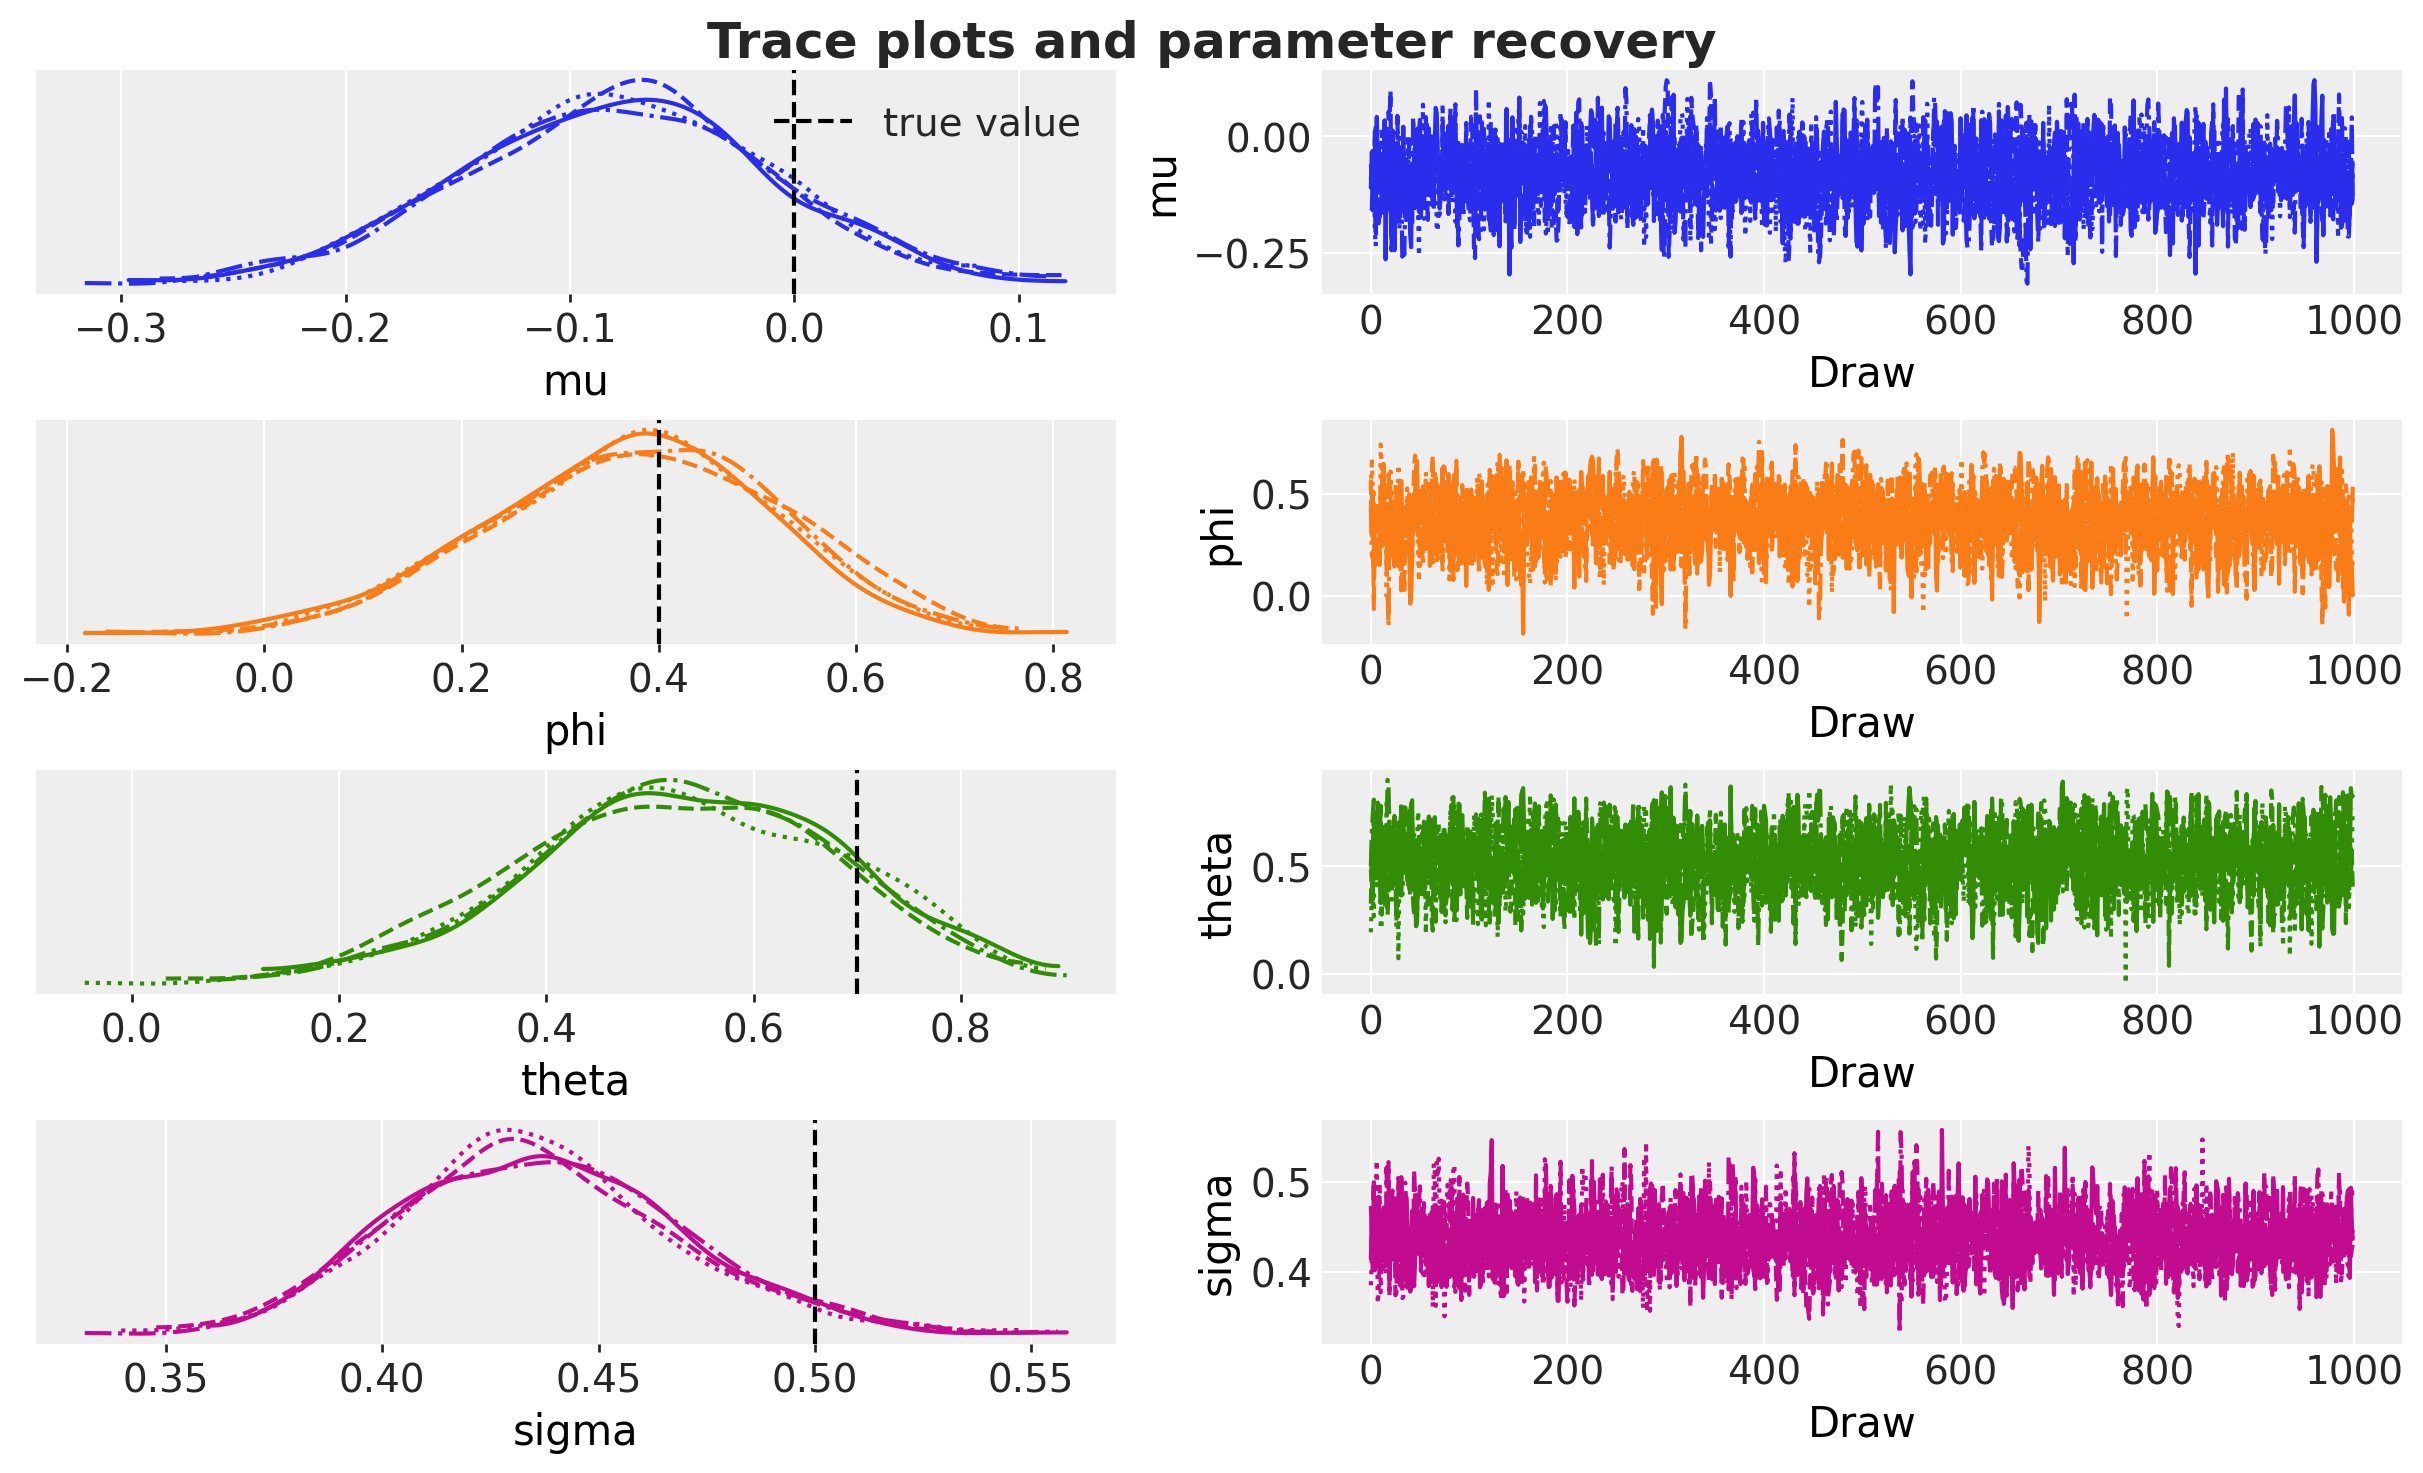

In [9]:
pc_trace = az.plot_trace_dist(
    tree,
    var_names=scalar_vars,
    compact=True,
    figure_kwargs={"figsize": (12, 7)},
)
for var_name in scalar_vars:
    ax_dist = pc_trace.viz["plot"][var_name].sel(column="dist").item()
    ax_dist.axvline(true_values[var_name], color="black", ls="--", lw=1.5, label="true value")
pc_trace.viz["plot"]["mu"].sel(column="dist").item().legend(loc="upper right")
pc_trace.viz["figure"].item().suptitle(
    "Trace plots and parameter recovery",
    fontsize=18,
    fontweight="bold",
    y=1.03,
);

## In-sample fit

Next we look at the one-step-ahead posterior predictive over the
training window, which `to_datatree` already sampled into the tree’s
`posterior_predictive` group: at each time step the predicted mean uses
the observed history up to the previous step, and the `"obs"` site adds
the observation noise. We only need to stack the chains back into a
single sample dimension to get the draws-first layout the plotting and
scoring helpers expect. We plot the posterior mean prediction together
with the $50\%$ and $94\%$ HDI bands (inner band darker, outer band
lighter) against the observed series with ArviZ `plot_lm`, packing the
draws with the package’s `predictions_to_datatree`, and score the fit
with the CRPS, a proper scoring rule that compares each observation to
the whole predictive distribution (lower is better).

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(

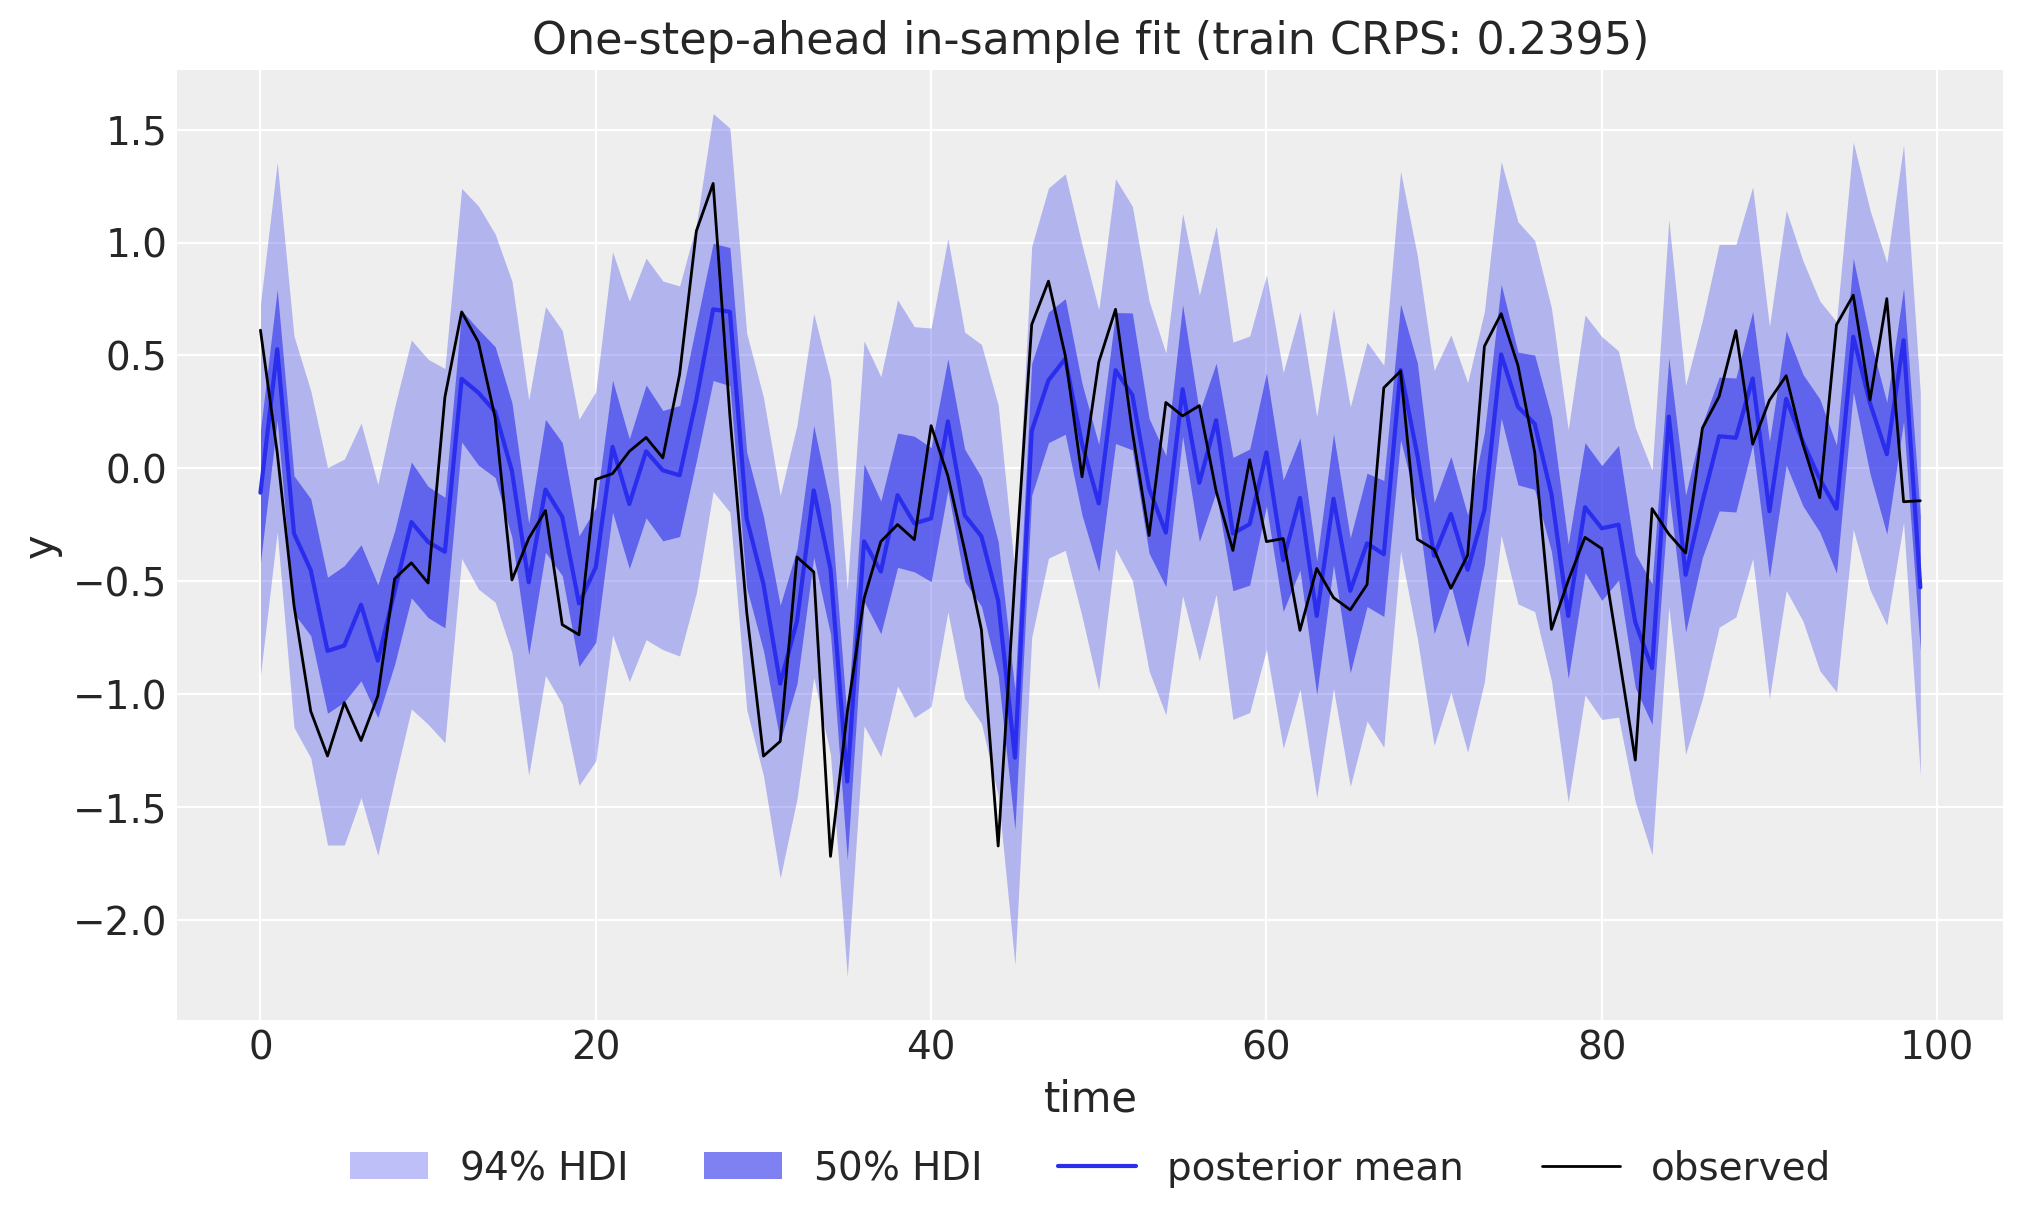

In [10]:
def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = [0.6, 0.3]  # 50% band darker, 94% band lighter

train_pp = (
    tree["posterior_predictive"]
    .dataset["obs"]
    .stack(sample=("chain", "draw"))
    .transpose("sample", "time", "obs_dim")
    .to_numpy()
)
crps_train = eval_crps(train_pp, data)

idata_in_sample = predictions_to_datatree(train_pp, time.astype(float), ["y"], observed=data)
pc = az.plot_lm(
    idata_in_sample,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": {"color": "C0", "alpha": 1.0, "width": 1.5},
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    figure_kwargs={"figsize": (10, 6)},
)
bands = pc.viz["ci_band"]["t"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(hdi_label(0.94))
band_50.set_label(hdi_label(0.5))
pe_line = pc.viz["pe_line"]["t"].item()
pe_line.set_label("posterior mean")
ax = pc.viz["figure"].item().axes[0]
(obs_line,) = ax.plot(time, np.asarray(y), color="black", lw=1, label="observed")
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
)
ax.set(
    title=f"One-step-ahead in-sample fit (train CRPS: {crps_train:.4f})",
    xlabel="time",
    ylabel="y",
);

## Expanding-window cross-validation

A single split tells us how the model does on one held-out window. A
more honest picture comes from *expanding-window* time-slice
cross-validation: we repeatedly move the train/test boundary forward,
refit from scratch, and forecast the next window, so every later part of
the series is scored out-of-sample exactly once.
`numpyro_forecast.backtest` runs this loop for us; the fitting and
forecasting inside each fold are delegated to two closures we write,
`forecast_fn` and `in_sample_fn`, so `backtest` itself has no opinion
about the inference engine. Both closures call `fit_nuts` on the fold’s
training window and then hand the draws to the package’s
[`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.forecast.html)
and
[`predict_in_sample`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.predict_in_sample.html)
drivers. Because `eval_train=True` scores the in-sample fit too, each
fold fits the sampler twice (once per closure).

We size the folds at roughly $10\%$ of the series: each fold forecasts
the next `10` steps (`test_window=10`), stepping forward `10` steps at a
time (`stride=10`) so the folds do not overlap, and the first `50`
observations (half the series) seed the initial training window
(`min_train_window=50`). That yields five folds with split points at
$t = 50, 60, 70, 80, 90$. With `eval_train=True` each fold also scores
its in-sample one-step-ahead posterior predictive with the same metrics
(this is what the series-as-covariates design buys us), and
`keep_predictions=True` retains the out-of-sample forecast samples so we
can plot them. `num_samples` records the ensemble size the closures
return: $4$ chains of $1{,}000$ draws, so `4_000` forecast paths per
fold. Alongside the CRPS we track the empirical **coverage** of the
central $50\%$ and $94\%$ intervals: a well-calibrated forecast covers
close to its nominal level.

In [11]:
def forecast_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with NUTS and forecast the test horizon."""
    key_fit, key_fc = random.split(rng_key)
    fold_posterior = fit_nuts(key_fit, model, train_data, train_covariates)
    return forecast(
        key_fc, model, fold_posterior, train_data, full_covariates, batch_size=batch_size
    )


def in_sample_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with NUTS and score its in-sample fit."""
    key_fit, key_pred = random.split(rng_key)
    fold_posterior = fit_nuts(key_fit, model, train_data, train_covariates)
    return predict_in_sample(
        key_pred, model, fold_posterior, train_covariates, batch_size=batch_size
    )


metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rng_key, rng_subkey = random.split(rng_key)
results = backtest(
    rng_subkey,
    lambda: arma_1_1,
    data,  # full dataset, no train/test split
    covariates,  # the series itself, sliced per fold by backtest
    forecast_fn=forecast_fn,
    in_sample_fn=in_sample_fn,
    metrics=metrics,
    test_window=10,  # ~10% of the series per fold
    stride=10,  # non-overlapping folds
    min_train_window=50,  # half the series seeds the first fold
    num_samples=4_000,  # 4 chains x 1,000 draws, what fit_nuts returns
    eval_train=True,
    keep_predictions=True,
)

split_points = [r.t1 for r in results]
train_crps = [r.train_metrics["crps"] for r in results]
test_crps = [r.metrics["crps"] for r in results]
test_cov_50 = [r.metrics["coverage_50"] for r in results]
test_cov_94 = [r.metrics["coverage_94"] for r in results]

print(f"folds: {len(results)} (split points: {split_points})")
print(f"mean in-sample CRPS:     {np.mean(train_crps):.4f}")
print(f"mean out-of-sample CRPS: {np.mean(test_crps):.4f}")
print(f"mean out-of-sample 50% coverage: {np.mean(test_cov_50):.2f}  (nominal 0.50)")
print(f"mean out-of-sample 94% coverage: {np.mean(test_cov_94):.2f}  (nominal 0.94)")

folds: 5 (split points: [50, 60, 70, 80, 90])
mean in-sample CRPS:     0.2399
mean out-of-sample CRPS: 0.2915
mean out-of-sample 50% coverage: 0.58  (nominal 0.50)
mean out-of-sample 94% coverage: 1.00  (nominal 0.94)

### Forecasts per fold

Overlaying every fold’s out-of-sample forecast (orange posterior mean
line plus $50\%$ and $94\%$ HDI bands, again inner darker and outer
lighter) on the observed series gives the rolling-origin view: each band
picks up where the previous fold’s training window ended, and the dashed
lines mark the successive train/test splits.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(

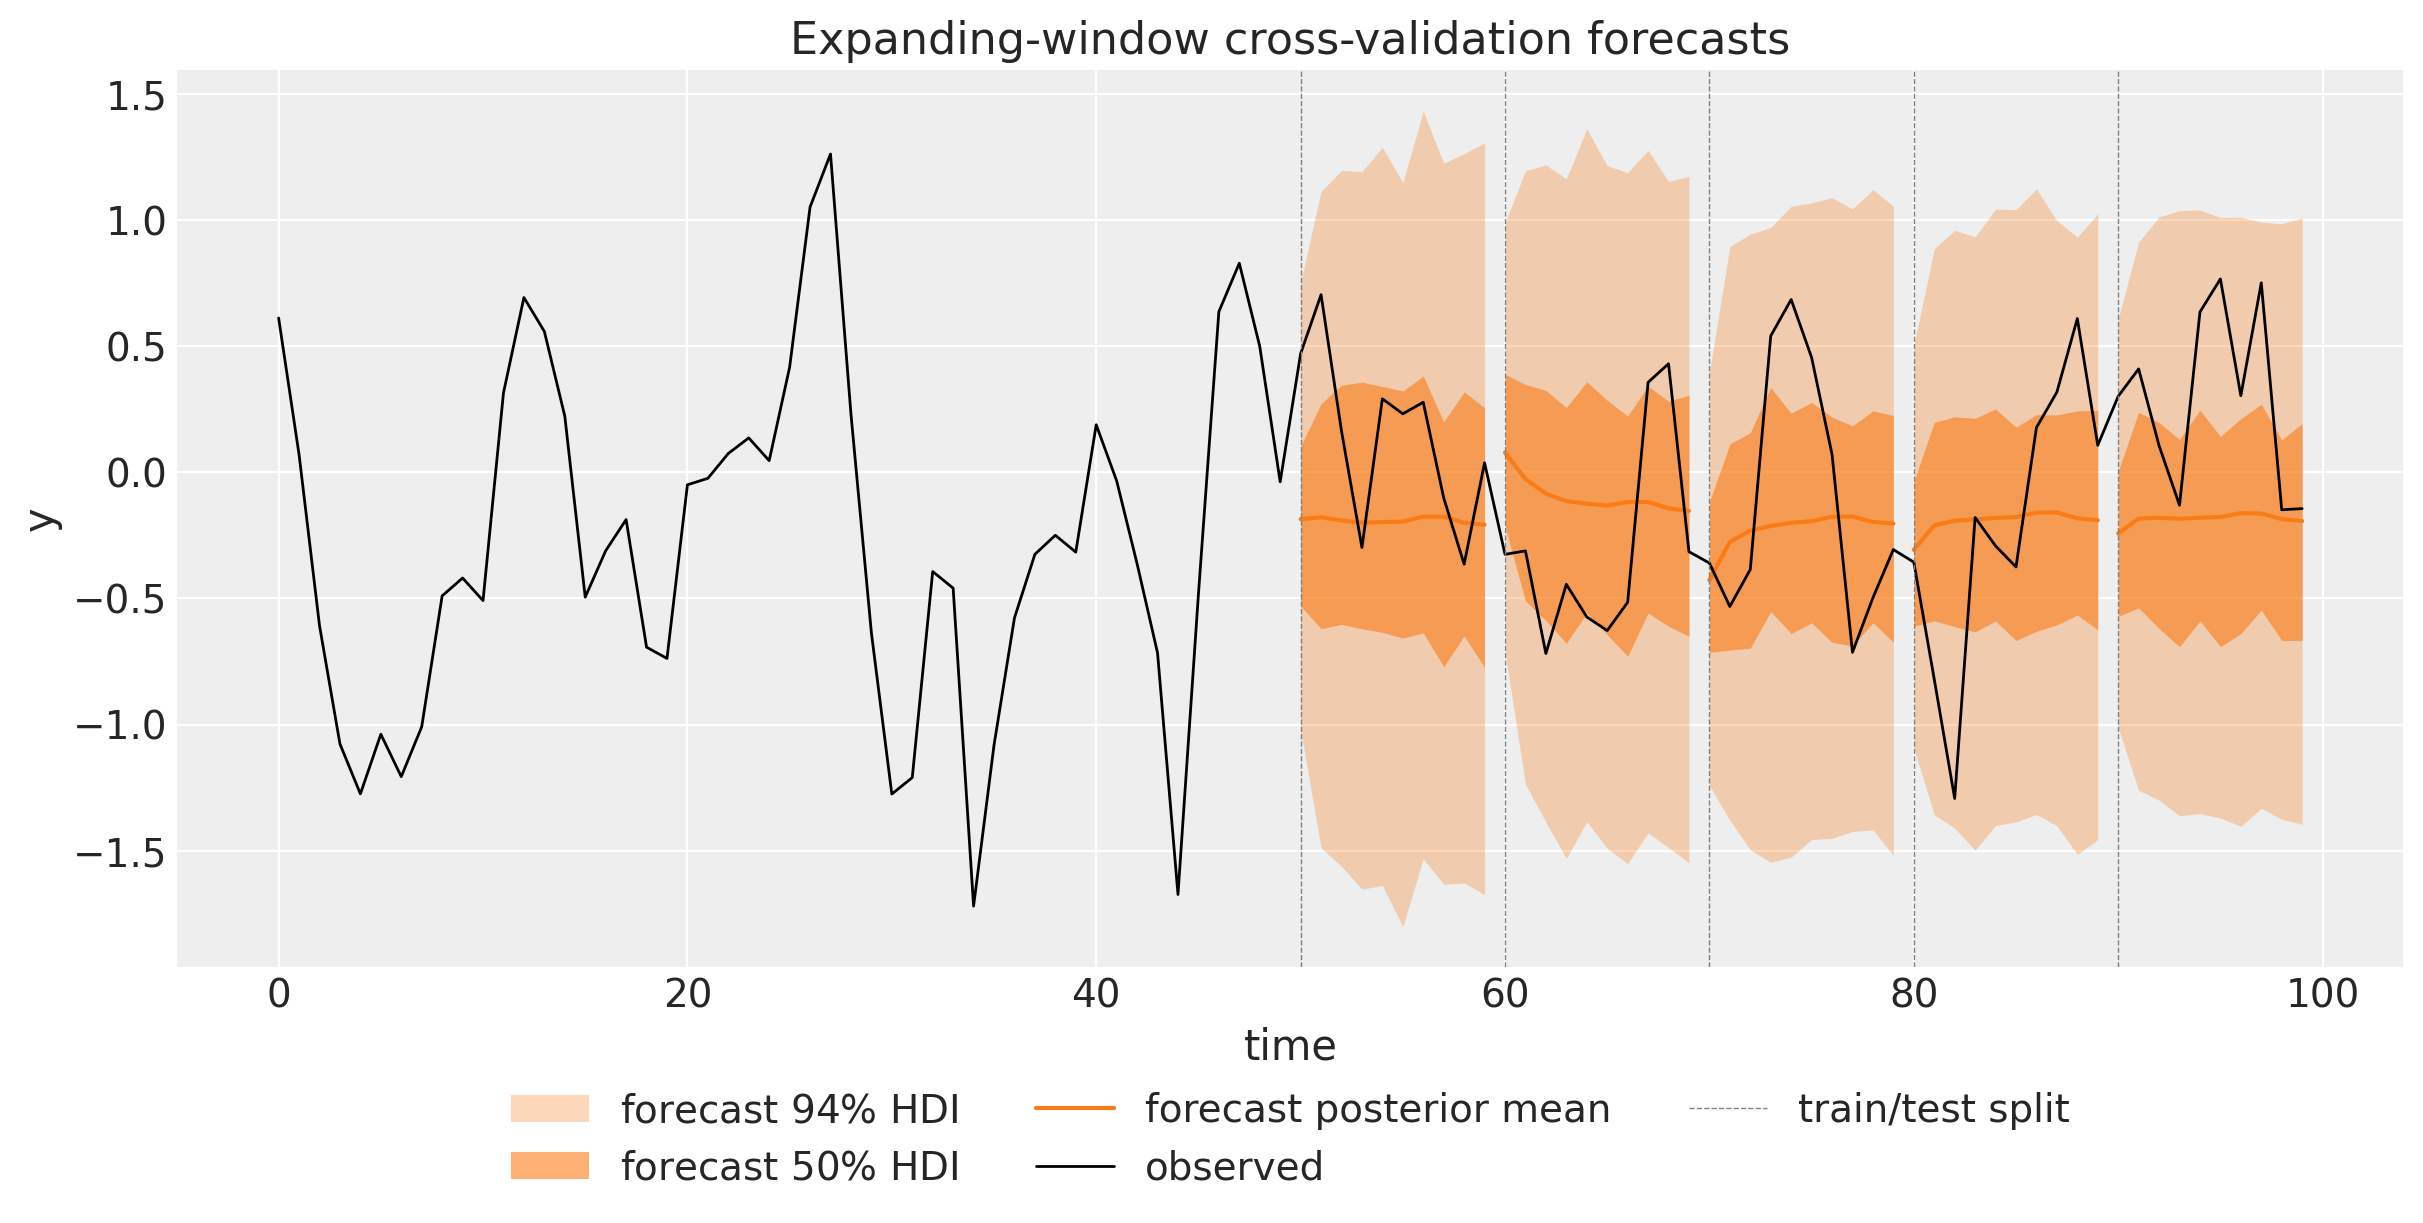

In [12]:
pc = None
for r in results:
    prediction = r.prediction
    if prediction is None:  # keep_predictions=True guarantees this never triggers
        continue
    fold_time = time[r.t1 : r.t2].astype(float)
    idata_fold = predictions_to_datatree(prediction, fold_time, ["y"], observed=data[r.t1 : r.t2])
    if pc is None:
        pc = az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C1", "alpha": 1.0, "width": 1.5},
            },
            aes={"alpha": ["prob"]},
            alpha=hdi_alphas,
            figure_kwargs={"figsize": (12, 6)},
        )
        bands = pc.viz["ci_band"]["t"]
        band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
        pe_line = pc.viz["pe_line"]["t"].item()
    else:
        az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C1", "alpha": 1.0, "width": 1.5},
            },
        )

if pc is None:
    msg = "no folds were plotted"
    raise ValueError(msg)
ax = pc.viz["figure"].item().axes[0]
band_94.set_label(hdi_label(0.94, prefix="forecast "))
band_50.set_label(hdi_label(0.5, prefix="forecast "))
pe_line.set_label("forecast posterior mean")
(obs_line,) = ax.plot(time, np.asarray(y), color="black", lw=1, label="observed")
split_lines = [
    ax.axvline(r.t1, color="gray", ls="--", lw=0.5, label="train/test split") for r in results
]
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line, split_lines[0]],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="Expanding-window cross-validation forecasts", xlabel="time", ylabel="y");

The bands show textbook ARMA behavior. Within each fold the forecast
mean decays toward the unconditional level at the geometric rate
$\phi^h$, so with $\phi = 0.4$ the memory of the last observation is
essentially gone after two or three steps and the band settles at the
*marginal* width of the process. This is not a defect: for a
short-memory process, reverting quickly to the stationary distribution
is exactly the right forecast, and what cross-validation checks here is
that the bands are the right width, in other words that the forecast is
calibrated.

### CRPS per fold

The per-fold CRPS quantifies the picture. The in-sample score is flat
across folds, while the out-of-sample score wanders within a narrow band
around it, the sampling noise you expect from just $10$ observations per
fold, with no widening gap between the two lines as the training window
grows. That is the signature of a model that is neither over- nor
under-fitting: with only four parameters and a correctly specified model
class, even the first fold’s $50$ observations pin the predictive
distribution down well.

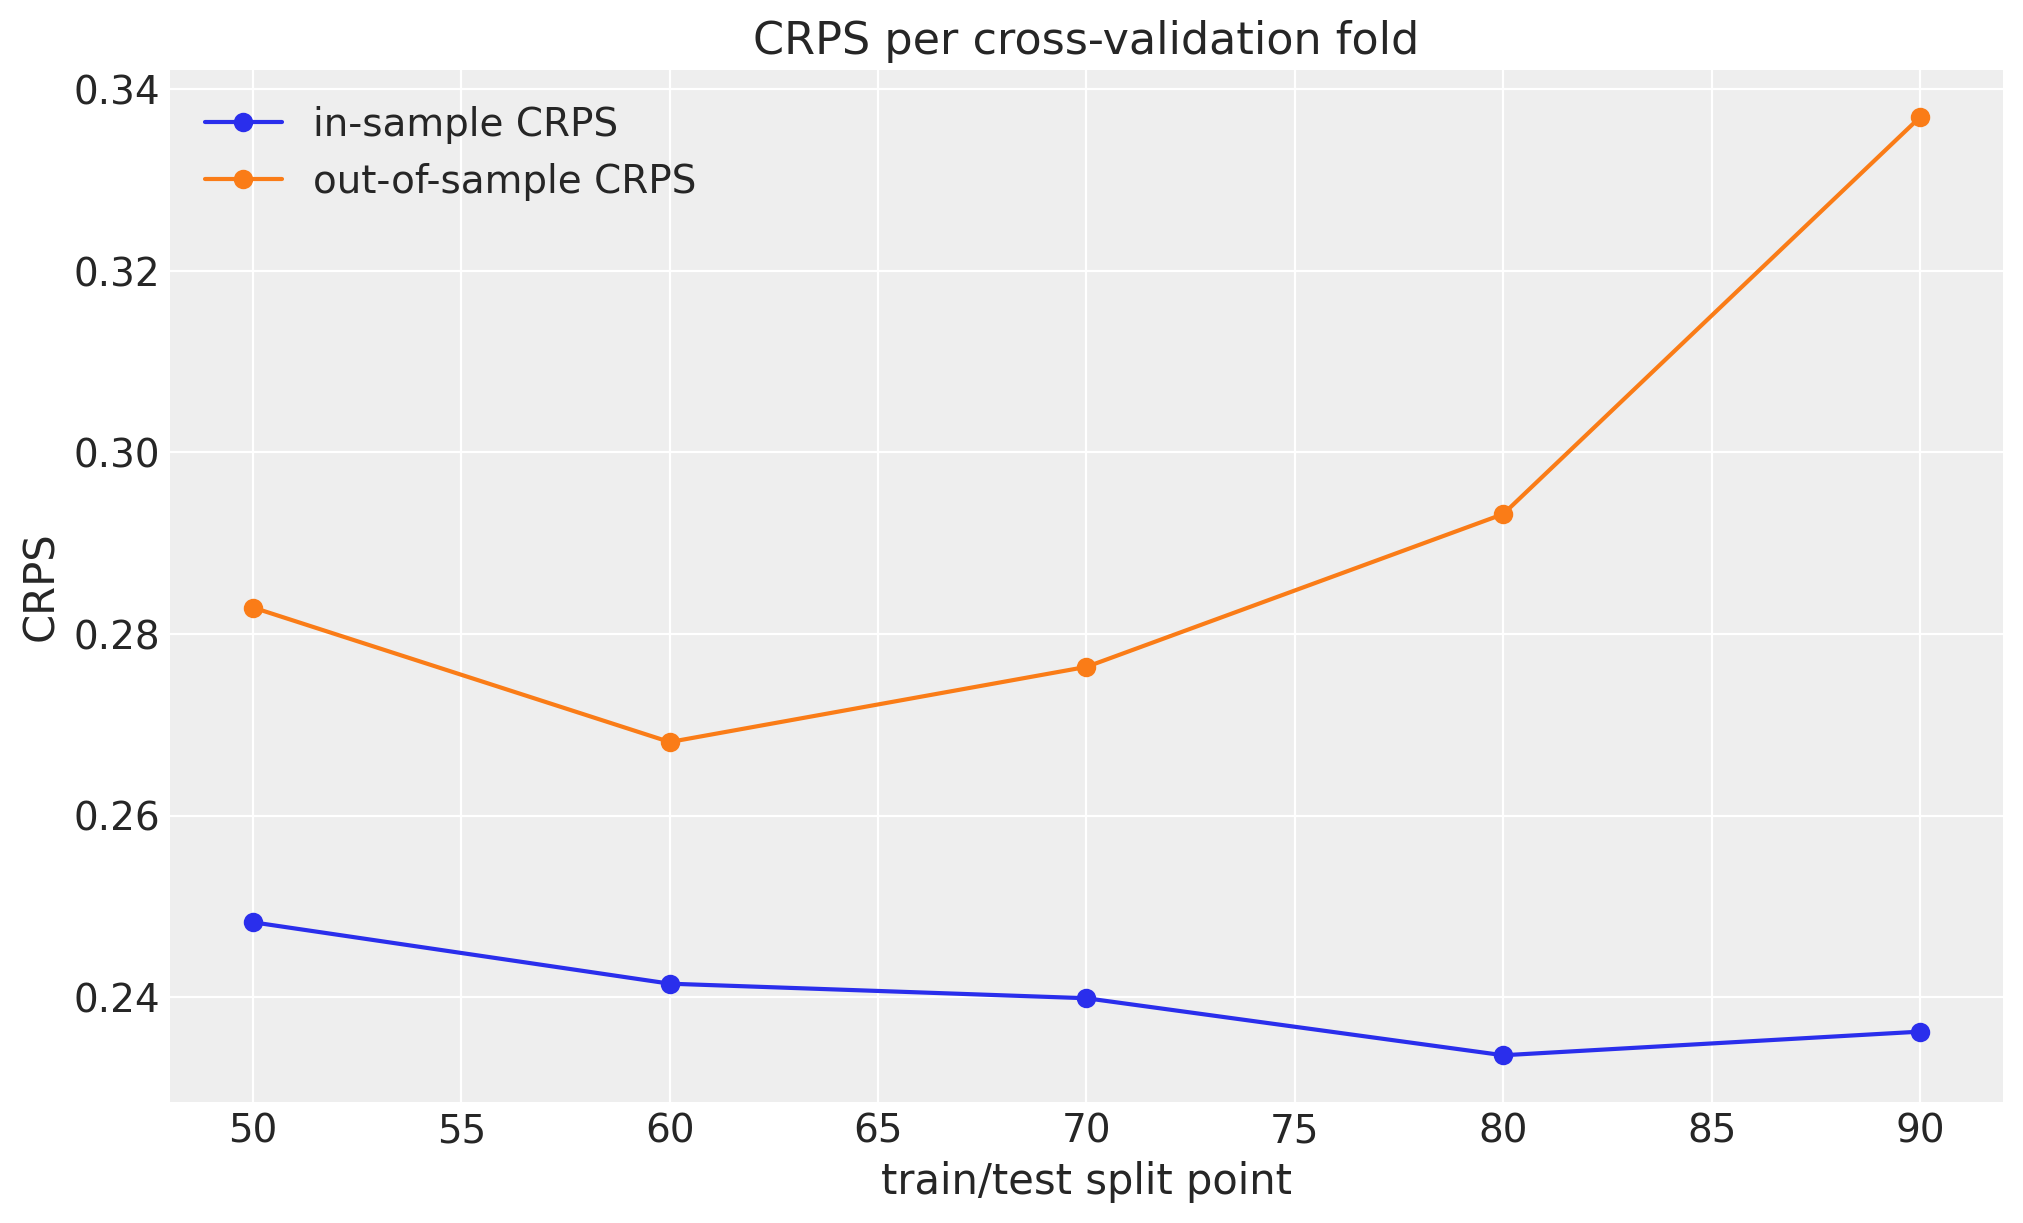

In [13]:
fig, ax = plt.subplots()
ax.plot(split_points, train_crps, "o-", color="C0", label="in-sample CRPS")
ax.plot(split_points, test_crps, "o-", color="C1", label="out-of-sample CRPS")
ax.legend()
ax.set(xlabel="train/test split point", ylabel="CRPS", title="CRPS per cross-validation fold");

### Forecast calibration

Finally we check the coverage: the fraction of held-out observations
that fall inside the central $50\%$ and $94\%$ prediction intervals of
their fold’s forecast. Well-calibrated forecasts should track the dashed
nominal levels; points above mean the bands are too wide
(under-confident), points below that they are too narrow
(over-confident). With only $10$ observations per fold the empirical
coverage is grainy (each observation moves it by $0.1$), so some wobble
around the nominal levels is expected.

A small caveat: `eval_coverage` measures coverage of the central
quantile interval, while the plotted bands are ArviZ HDIs. For the
near-symmetric Gaussian predictive here the two nearly coincide, so this
is a faithful check of the bands shown above.

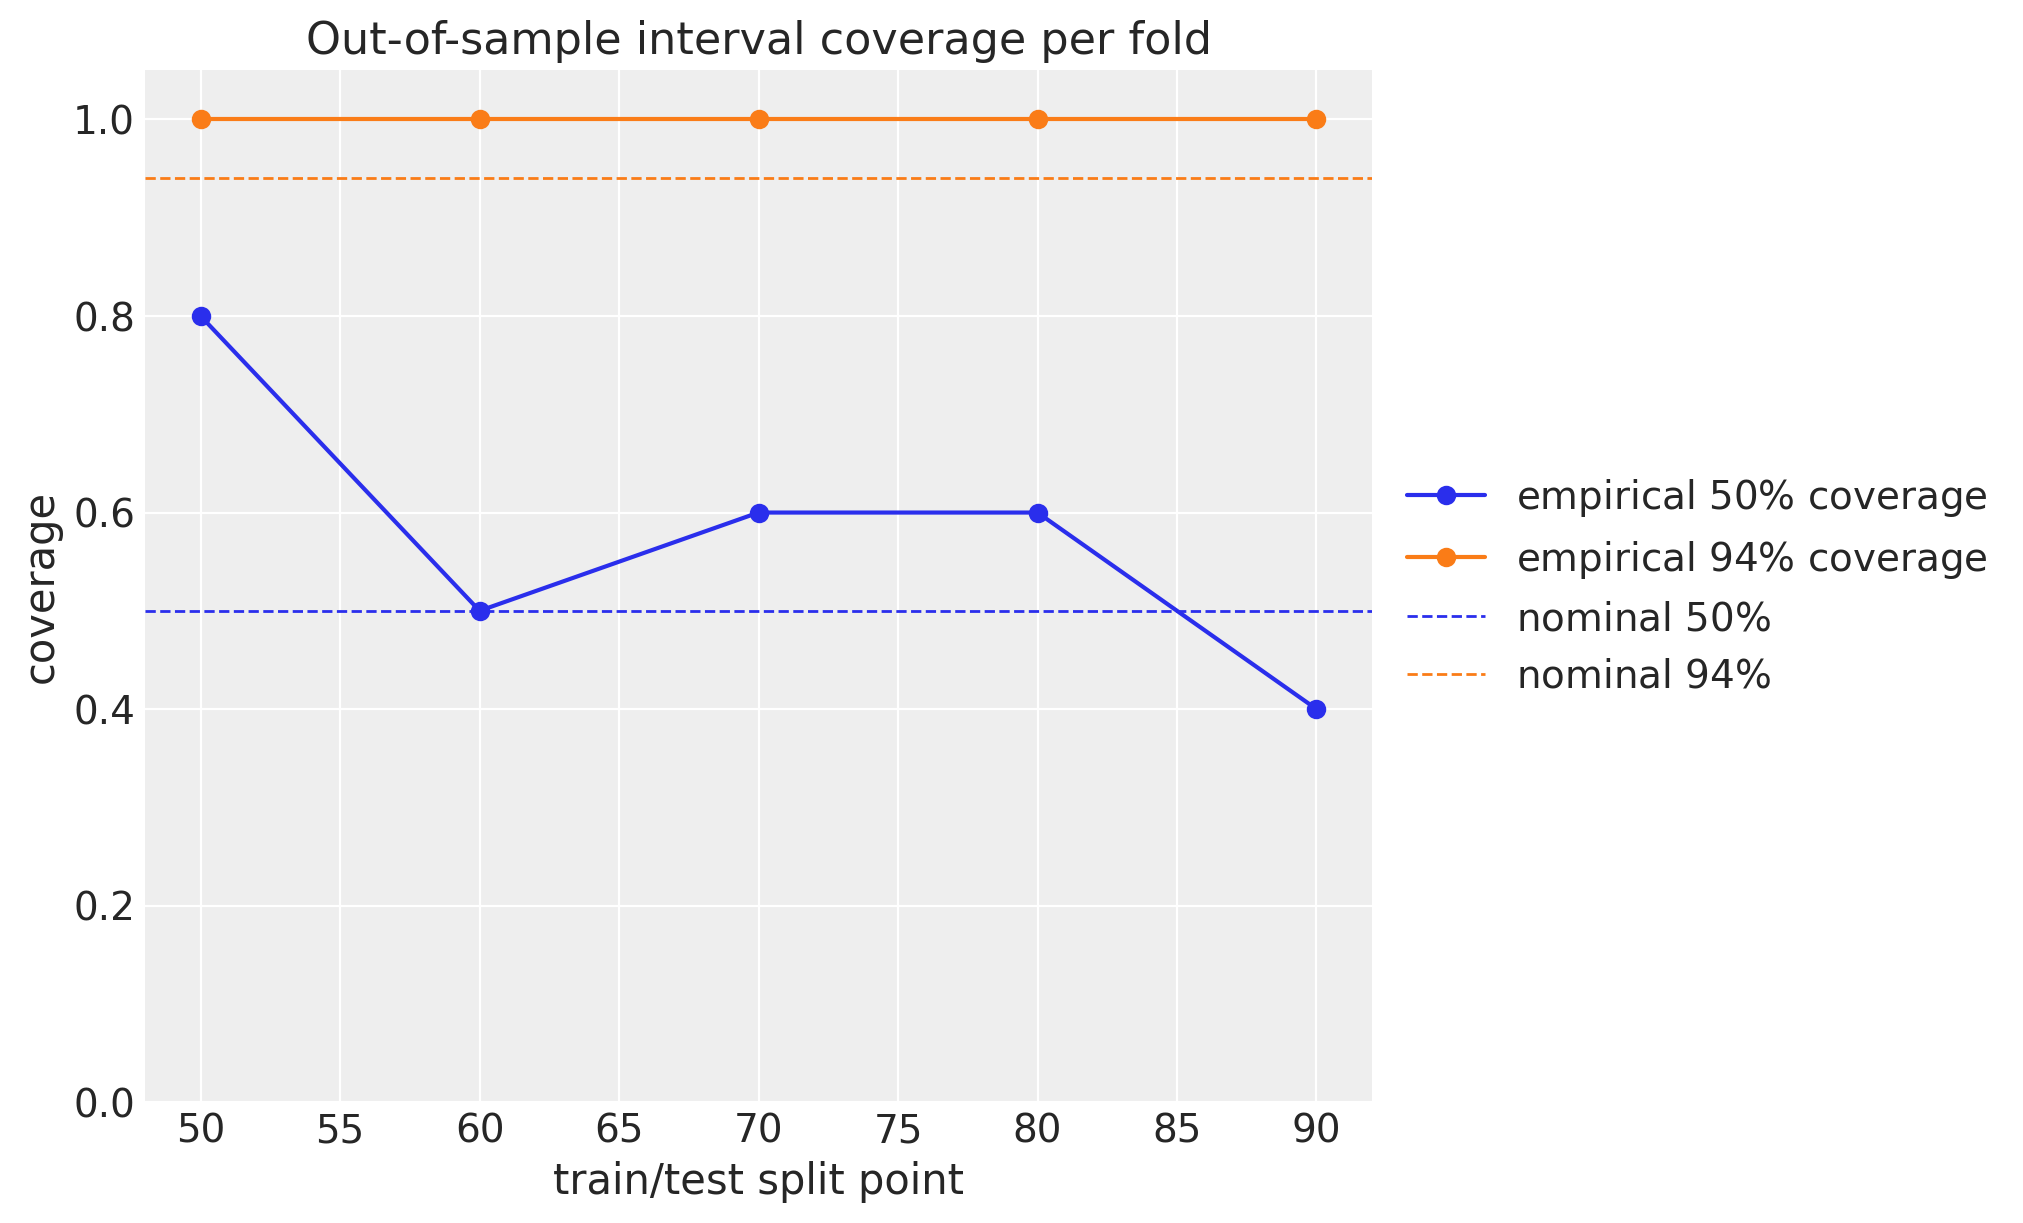

In [14]:
fig, ax = plt.subplots()
ax.plot(split_points, test_cov_50, "o-", color="C0", label=r"empirical $50\%$ coverage")
ax.plot(split_points, test_cov_94, "o-", color="C1", label=r"empirical $94\%$ coverage")
ax.axhline(0.5, color="C0", ls="--", lw=1, label=r"nominal $50\%$")
ax.axhline(0.94, color="C1", ls="--", lw=1, label=r"nominal $94\%$")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(
    xlabel="train/test split point",
    ylabel="coverage",
    title="Out-of-sample interval coverage per fold",
    ylim=(0, 1.05),
);

## References

- Orduz, J. [*Notes on an ARMA(1,1) Model with
  NumPyro*](https://juanitorduz.github.io/arma_numpyro/). The blog post
  this notebook ports.
- Hyndman, R. J., & Athanasopoulos, G. (2021). [*Forecasting: Principles
  and Practice*](https://otexts.com/fpp3/), 3rd edition. Chapter 9:
  ARIMA models.
- NumPyro documentation: [Example: AR(2)
  process](https://num.pyro.ai/en/stable/examples/ar2.html).
- The [exponential smoothing
  example](https://juanitorduz.github.io/numpyro_forecast/docs/examples/exponential_smoothing_state_space.html)
  in this documentation, which uses the same `ssoe` building block for
  an error-feedback model.
- The [univariate forecasting
  example](https://juanitorduz.github.io/numpyro_forecast/docs/examples/forecasting_univariate.html)
  in this documentation, which introduces `backtest` and the per-fold
  evaluation workflow.